In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import VotingClassifier
from itertools import cycle
import numpy as np
import os

In [18]:
def load_and_preprocess_data():
    """Loads and preprocesses the dataset."""
    df = pd.read_csv('Datasets/cleaned_stations.csv', skiprows=[1])

    for col in df.columns:
        if col not in ['station_code', 'monitoring_location', 'state_name']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
    df.dropna(subset=target_features, inplace=True)

    def classify_wqi(row):
        if row['do_max'] > 6.5 and row['bod_max'] < 2 and row['fecal_coliform_max'] < 100:
            return 'Good'
        elif 5 < row['do_max'] <= 6.5 and 2 <= row['bod_max'] < 5 and 100 <= row['fecal_coliform_max'] < 1000:
            return 'Moderate'
        else:
            return 'Poor'
    df['wqi_category'] = df.apply(classify_wqi, axis=1)

    if df['wqi_category'].nunique() < 2:
        print("The created target variable 'wqi_category' has only one class. Cannot proceed.")
        return None, None, None

    features = [col for col in df.columns if '_min' in col or '_max' in col] + ['state_name']
    X = df[features].copy()
    y = df['wqi_category'] # FIX: Keep y as strings to match model predictions

    for col in X.select_dtypes(include=['number']).columns:
        X[col].fillna(X[col].mean(), inplace=True)
            
    # Note: This assumes the state encoding order matches the one used during training.
    # Ideally, one should load the fitted state_encoder used during training.
    state_encoder = LabelEncoder()
    X['state_name'] = state_encoder.fit_transform(X['state_name'].astype(str))
    
    # We do not return y_encoded anymore, just y (strings)
    # Class names can be extracted directly
    class_names = np.unique(y)
    
    return X, y, class_names

In [19]:
def evaluate_models(X_test, y_test, class_names):
    """Loads models, creates an ensemble, evaluates all, and generates plots."""
    print("\nLoading models and evaluating...")

    model_paths = {
        'rf': 'models/random_forest_model.joblib',
        'svm': 'models/svm_model.joblib',
        'knn': 'models/knn_model.joblib',
        'dt': 'models/decision_tree_model.joblib',
        # 'nb': 'models/naive_bayes_model.joblib',
        'scaler': 'models/scaler.joblib'
    }

    loaded_objects = {}
    for name, path in model_paths.items():
        if os.path.exists(path):
            loaded_objects[name] = joblib.load(path)
        else:
            print(f"Warning: {path} not found. Skipping {name}.")
            if name == 'scaler':
                print("Critical: Scaler not found. Cannot proceed with scaling-dependent models.")
                return

    rf = loaded_objects.get('rf')
    svm = loaded_objects.get('svm')
    knn = loaded_objects.get('knn')
    dt = loaded_objects.get('dt')
    # nb = loaded_objects.get('nb')
    scaler = loaded_objects.get('scaler')

    # Scale test data
    X_test_scaled = scaler.transform(X_test)
    
    # Create Ensemble Model
    # Only include models that were successfully loaded
    estimators = []
    if rf: estimators.append(('rf', rf))
    if knn: estimators.append(('knn', knn))
    if dt: estimators.append(('dt', dt))
    # if nb: estimators.append(('nb', nb))
    if svm: estimators.append(('svm', svm))

    if not estimators:
        print("No models loaded. Exiting.")
        return

    voting_clf = VotingClassifier(estimators=estimators, voting='hard')
    # Fit on test data (as per original script logic, though unorthodox)
    # Now fitting with string labels, which VotingClassifier supports
    voting_clf.fit(X_test_scaled, y_test) 

    models = {}
    if rf: models["Random Forest"] = rf
    if knn: models["k-NN"] = knn
    if dt: models["Decision Tree"] = dt
    # if nb: models["Naive Bayes"] = nb
    if svm: models["Support Vector Machine"] = svm
    models["Ensemble (Hard Voting)"] = voting_clf
    
    models_require_scaling = ["k-NN", "Naive Bayes", "Support Vector Machine", "Ensemble (Hard Voting)"]
    accuracies = {}
    precisions = {}
    f1_scores = {}
    recall_scores = {}
    predictions = {}
    
    print("\n--- Model Accuracy ---")
    for name, model in models.items():
        if name in models_require_scaling:
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = model.predict(X_test)
        
        predictions[name] = y_pred
        accuracies[name] = accuracy_score(y_test, y_pred)
        precisions[name] = precision_score(y_test, y_pred, average="weighted")
        f1_scores[name] = f1_score(y_test, y_pred, average="weighted")
        recall_scores[name] = recall_score(y_test, y_pred, average="weighted")
        print(f"Accuracy for {name}: {accuracies[name]:.4f}")

    # 1. Accuracy Comparison Plot
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x=list(accuracies.keys()),
        y=list(accuracies.values())
    )

    plt.title('Model Accuracy Comparison')
    plt.ylabel('Accuracy')
    plt.xlabel('Model')
    plt.xticks(rotation=45)

    # Display accuracy value on top of each bar
    for i, accuracy in enumerate(accuracies.values()):
        ax.text(
            i,
            accuracy + 0.01,
            f'{accuracy:.2%}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    # Give some space above the highest bar
    plt.ylim(0, 1.05)

    plt.tight_layout()
    plt.savefig("Graphs/model_accuracy_comparison.png", dpi=300)
    plt.show()

    print("\nSaved model_accuracy_comparison.png")

    # 2. Confusion Matrices
    fig, axes = plt.subplots(1, len(models), figsize=(25, 5))
    if len(models) == 1: axes = [axes] # Handle single model case
    
    for i, (name, model) in enumerate(models.items()):
        cm = confusion_matrix(y_test, predictions[name], labels=class_names)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        axes[i].set_title(name)
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    plt.tight_layout()
    plt.savefig("Graphs/confusion_matrices.png")
    print("Saved confusion_matrices.png")

    # 3. ROC Curves (One-vs-Rest for multi-class)
    plt.figure(figsize=(12, 10))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])

    for name, model in models.items():
        if "Ensemble" in name: 
            continue
            
        if hasattr(model, "predict_proba"):
            if name in models_require_scaling:
                y_prob = model.predict_proba(X_test_scaled)
            else:
                y_prob = model.predict_proba(X_test)
        else:
            continue

        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        # y_test is strings, so we compare directly with class names
        for i, class_name in enumerate(class_names):
            # Create binary target for this class
            binary_y_test = (y_test == class_name).astype(int)
            fpr[i], tpr[i], _ = roc_curve(binary_y_test, y_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Aggregate ROC AUC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(class_names)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(class_names)
        
        roc_auc_macro = auc(all_fpr, mean_tpr)

        plt.plot(all_fpr, mean_tpr, color=next(colors), lw=2,
                 label=f'{name} (AUC = {roc_auc_macro:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC Curve Comparison (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig("Graphs/roc_curve_comparison.png")
    print("Saved roc_curve_comparison.png")

    results_df = pd.DataFrame({
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recall_scores,
    "F1 Score": f1_scores
    })

    results_df.reset_index(inplace=True)
    results_df.columns = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score"]

    return results_df

/tmp/ipykernel_156078/1135543389.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X[col].fillna(X[col].mean(), inplace=True)
/home/linuxuser/Downloads/Ganga-Cleaning-mission/.venv/lib64/python3.14/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when usi

Data loaded: X shape=(1425, 19), y shape=(1425,), Classes=['Good' 'Moderate' 'Poor']

Loading models and evaluating...

--- Model Accuracy ---
Accuracy for Random Forest: 0.8175
Accuracy for k-NN: 0.8982
Accuracy for Decision Tree: 0.8175


/home/linuxuser/Downloads/Ganga-Cleaning-mission/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy for Support Vector Machine: 0.8421
Accuracy for Ensemble (Hard Voting): 0.9579


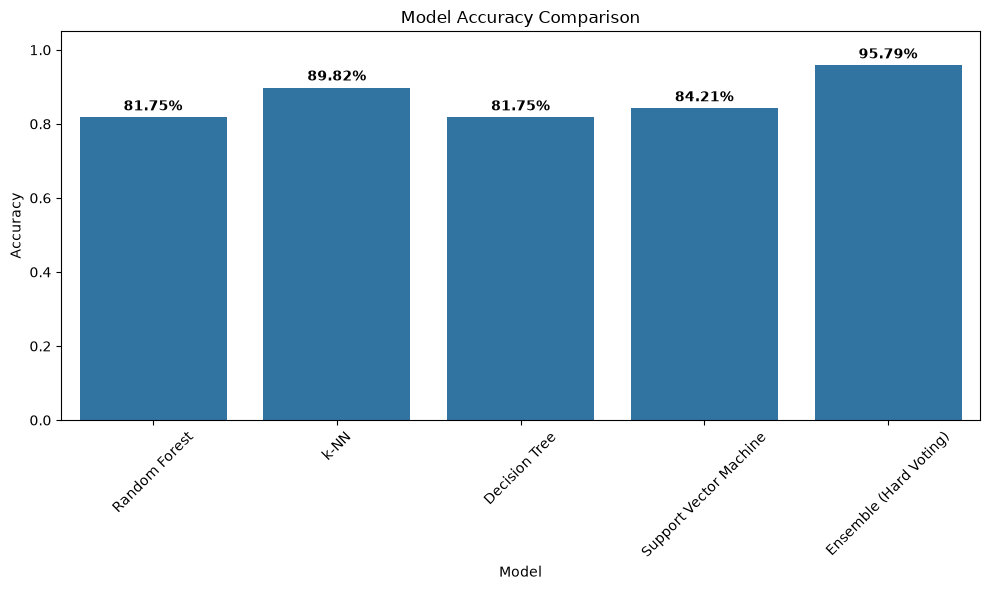


Saved model_accuracy_comparison.png
Saved confusion_matrices.png
Saved roc_curve_comparison.png


/home/linuxuser/Downloads/Ganga-Cleaning-mission/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/home/linuxuser/Downloads/Ganga-Cleaning-mission/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


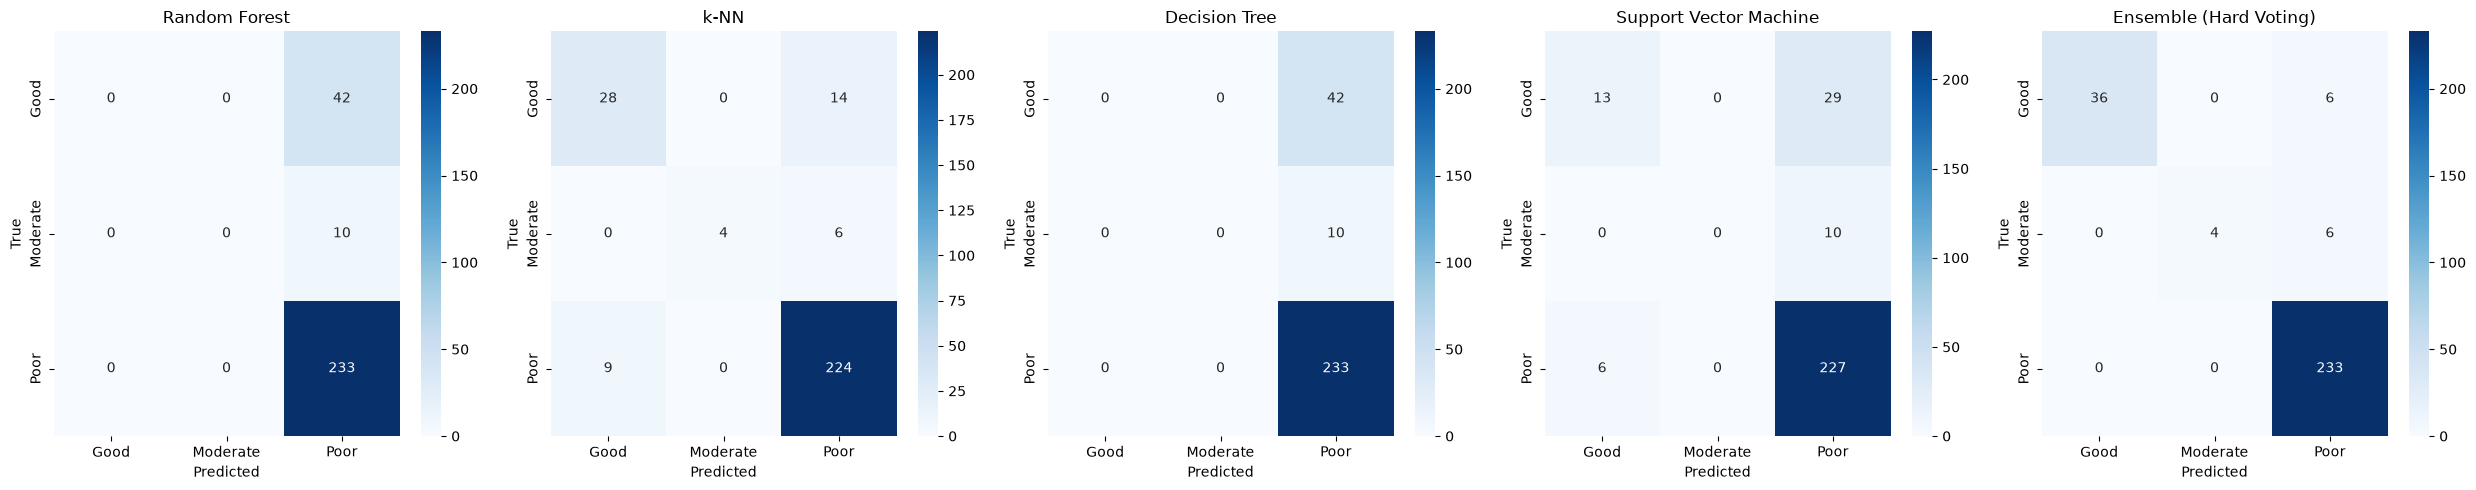

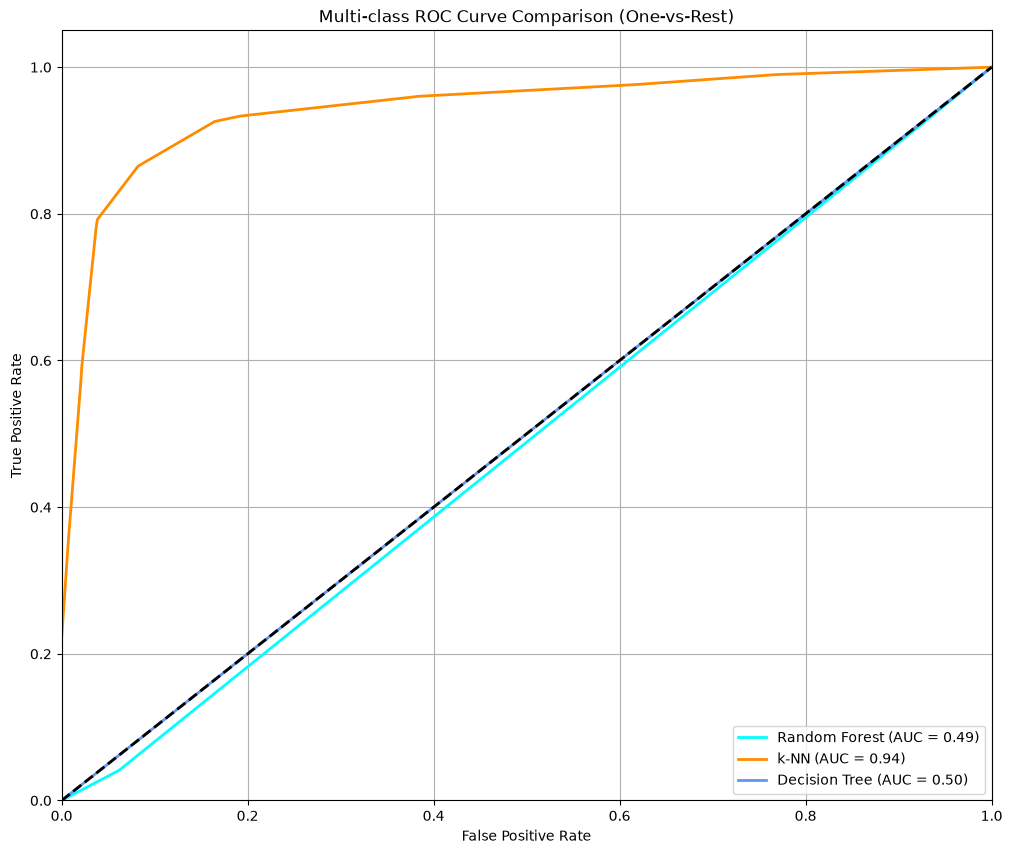

In [20]:
X, y, class_names = load_and_preprocess_data()
if X is not None:
    print(f"Data loaded: X shape={X.shape}, y shape={y.shape}, Classes={class_names}")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    data_df = evaluate_models(X_test, y_test, class_names)

In [21]:
data_df

,Classifier,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.817544,0.668378,0.817544,0.735474
1,k-NN,0.898246,0.897142,0.898246,0.892354
2,Decision Tree,0.817544,0.668378,0.817544,0.735474
3,Support Vector Machine,0.842105,0.798509,0.842105,0.806630
4,Ensemble (Hard Voting),0.957895,0.959957,0.957895,0.953102


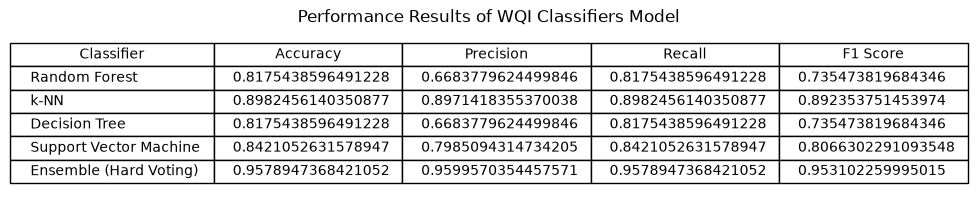

In [22]:
table_df = data_df
# table_df = data_df.round(2)

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis("off")

table = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc="center",
    cellLoc="left"
)

# Formatting
table.auto_set_font_size(True)
table.scale(1, 1.4)

table.auto_set_column_width(col=list(range(len(table_df.columns))))

# Title
plt.title(
    "Performance Results of WQI Classifiers Model", fontsize=12, pad=10
)

# plt.savefig(
#     "Graphs/Performance_Results_of_WQI_Classifiers_Model.png", dpi=300, bbox_inches="tight"
# )

plt.show()